#  Importação de bibliotecas e Configuração do Estilo dos Gráficos

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal 

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Modelagem da Planta (Estufa Térmica)

In [4]:
# Parâmetros hipotéticos da estufa
K_planta = 2.5    # Ganho estático (Ex: 2.5 °C por % de PWM)
tau_planta = 60.0 # Constante de tempo (60 segundos de inércia térmica) 

num_planta = [K_planta]
den_planta = [tau_planta, 1.0]

# Criação da Função de Transferência G(s)

In [5]:
planta = signal.TransferFunction(num_planta, den_planta)

print(f"Função de Transferência da Planta G(s): {K_planta} / ({tau_planta}s + 1)")
print(f"Polo da malha aberta: {planta.poles[0]:.4f}")

Função de Transferência da Planta G(s): 2.5 / (60.0s + 1)
Polo da malha aberta: -0.0167


# Análise de Polos e Resposta em Malha Aberta

In [7]:
t_aberta = np.linspace(0, 400, 1000)
tempo_aberta, resposta_aberta = signal.step(planta, T=t_aberta)


# Gráfico 1: Mapa de Polos e Zeros e Gráfico 2: Resposta ao Degrau em Malha Aberta

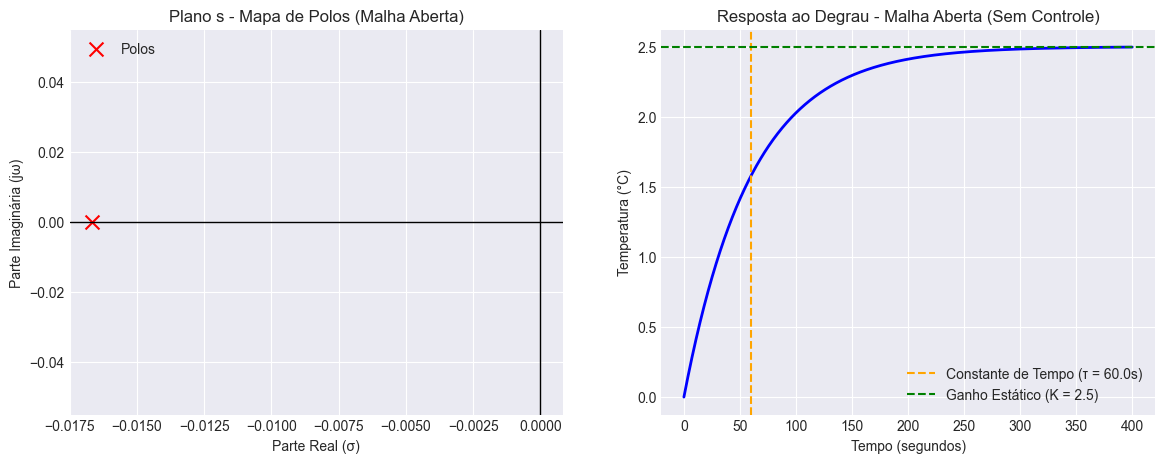

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 

# Gráfico 1: Mapa de Polos

ax1.scatter(np.real(planta.poles), np.imag(planta.poles), marker='x', color='red', s=100, label='Polos')
ax1.axvline(0, color='black', lw=1)
ax1.axhline(0, color='black', lw=1)
ax1.set_title('Plano s - Mapa de Polos (Malha Aberta)')
ax1.set_xlabel('Parte Real (σ)')
ax1.set_ylabel('Parte Imaginária (jω)')
ax1.grid(True)
ax1.legend()  

# Gráfico 2: Resposta ao Degrau em Malha Aberta 
ax2.plot(tempo_aberta, resposta_aberta, color='blue', lw=2)
ax2.axvline(tau_planta, color='orange', linestyle='--', label=f'Constante de Tempo (τ = {tau_planta}s)')
ax2.axhline(K_planta, color='green', linestyle='--', label=f'Ganho Estático (K = {K_planta})')
ax2.set_title('Resposta ao Degrau - Malha Aberta (Sem Controle)')
ax2.set_xlabel('Tempo (segundos)')
ax2.set_ylabel('Temperatura (°C)')
ax2.legend()
plt.show()

# Projeto do Controlador PID e Malha Fechada

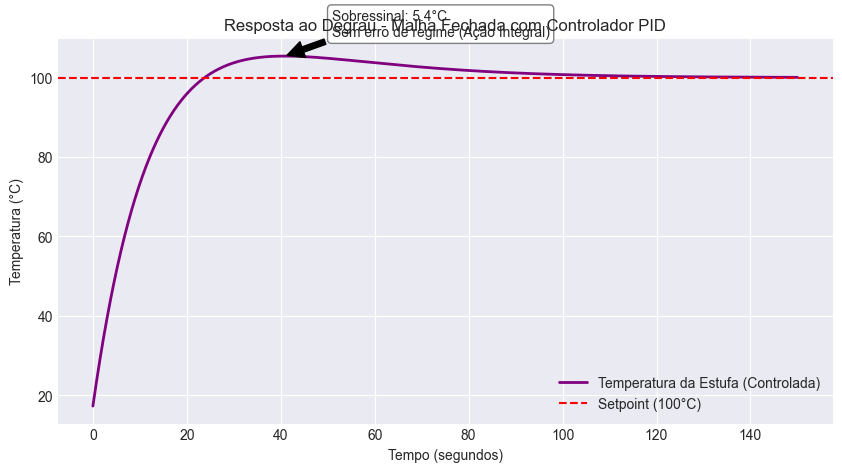

Análise de Estabilidade (Malha Fechada):
Polo 1: -0.0586+0.0034j
Polo 2: -0.0586-0.0034j

Conclusão: Como todos os polos possuem parte real negativa, o sistema controlado é ESTÁVEL.


In [11]:
# --- Controlador PID (C(s) = Kp + Ki/s + Kd*s) ---
Kp = 3.0   # Ação Proporcional
Ki = 0.1   # Ação Integral
Kd = 5.0   # Ação Derivativa

# Transformando o PID em Função de Transferência: C(s) = (Kd*s^2 + Kp*s + Ki) / s
num_pid = [Kd, Kp, Ki]
den_pid = [1, 0]

# --- Fechando a Malha ---
# Malha Aberta = C(s) * G(s)
num_aberta = np.convolve(num_pid, num_planta)
den_aberta = np.convolve(den_pid, den_planta)

# Malha Fechada H(s) = (C(s)G(s)) / (1 + C(s)G(s))
num_fechada = num_aberta
den_fechada = np.polyadd(den_aberta, num_aberta)

sistema_fechada = signal.TransferFunction(num_fechada, den_fechada)

# --- Simulação da Resposta do Sistema Controlado ---
# Setpoint de 100°C aplicado no tempo t=0
setpoint = 100.0
t_fechada = np.linspace(0, 150, 1000)
tempo_fechada, resposta_fechada = signal.step(sistema_fechada, T=t_fechada)

# Multiplicando pela amplitude do setpoint
resposta_fechada = resposta_fechada * setpoint

# Plotagem
plt.figure(figsize=(10, 5))
plt.plot(tempo_fechada, resposta_fechada, color='purple', lw=2, label='Temperatura da Estufa (Controlada)')
plt.axhline(setpoint, color='red', linestyle='--', label='Setpoint (100°C)')

# Calculando e exibindo métricas de controle
sobressinal = max(resposta_fechada) - setpoint
plt.annotate(f'Sobressinal: {sobressinal:.1f}°C\nSem erro de regime (Ação Integral)', 
             xy=(tempo_fechada[np.argmax(resposta_fechada)], max(resposta_fechada)),
             xytext=(tempo_fechada[np.argmax(resposta_fechada)] + 10, max(resposta_fechada) + 5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

plt.title('Resposta ao Degrau - Malha Fechada com Controlador PID')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Análise de Polos da Malha Fechada
print("Análise de Estabilidade (Malha Fechada):")
for i, polo in enumerate(sistema_fechada.poles):
    print(f"Polo {i+1}: {polo:.4f}")
print("\nConclusão: Como todos os polos possuem parte real negativa, o sistema controlado é ESTÁVEL.")